In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [2]:
df = pd.read_csv("../data/Telco-Customer-Churn.csv")
df = df.drop("customerID", axis=1)

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna()

In [3]:
# Map target variable
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

In [4]:
# Apply One-Hot Encoding to the entire dataframe first
# Using drop_first=True is recommended for Logistic Regression
df = pd.get_dummies(df, drop_first=True)

In [5]:
y = df["Churn"]
X = df.drop("Churn", axis=1)

In [6]:
df = pd.get_dummies(df, drop_first=False)

Train Test Split

In [7]:
# Split the encoded data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Scaling

In [8]:
# Scaling section
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
# Example: Logistic Regression training
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train) # Use scaled data!
# Prediction
y_pred_lr = lr.predict(X_test_scaled)

MODEL 1 — KNN

In [10]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

MODEL 2 — Logistic Regression

In [11]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

C:\Users\This Pc\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


MODEL 3 — Decision Tree

In [12]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

MODEL 4 — Random Forest

In [13]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

EVALUATION (ALL MODELS)

In [14]:
def evaluate(name, y_test, y_pred):
    print("\n", name)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))

In [15]:
evaluate("KNN", y_test, y_pred_knn)
evaluate("Logistic Regression", y_test, y_pred_lr)
evaluate("Decision Tree", y_test, y_pred_dt)
evaluate("Random Forest", y_test, y_pred_rf)


 KNN
Accuracy: 0.7704335465529495
Precision: 0.5888501742160279
Recall: 0.45187165775401067
F1 Score: 0.5113464447806354

 Logistic Regression
Accuracy: 0.7874911158493249
Precision: 0.6205787781350482
Recall: 0.516042780748663
F1 Score: 0.5635036496350365

 Decision Tree
Accuracy: 0.7249466950959488
Precision: 0.4838709677419355
Recall: 0.5213903743315508
F1 Score: 0.5019305019305019

 Random Forest
Accuracy: 0.7853589196872779
Precision: 0.6267605633802817
Recall: 0.47593582887700536
F1 Score: 0.541033434650456


CONFUSION MATRIX

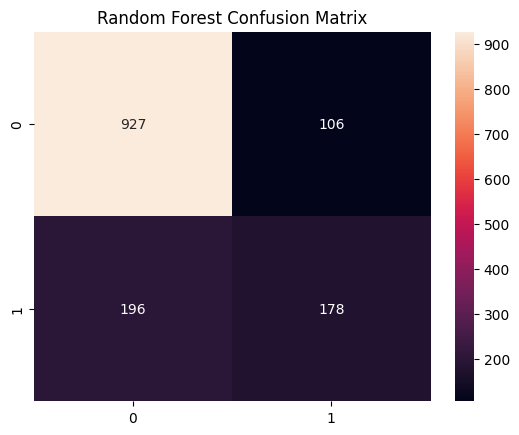

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Random Forest Confusion Matrix")
plt.show()

In [17]:
models = {
    "KNN": accuracy_score(y_test, y_pred_knn),
    "Logistic Regression": accuracy_score(y_test, y_pred_lr),
    "Decision Tree": accuracy_score(y_test, y_pred_dt),
    "Random Forest": accuracy_score(y_test, y_pred_rf)
}

best_model = max(models, key=models.get)

print("Best Model:", best_model)
print(models)

Best Model: Logistic Regression
{'KNN': 0.7704335465529495, 'Logistic Regression': 0.7874911158493249, 'Decision Tree': 0.7249466950959488, 'Random Forest': 0.7853589196872779}


In [18]:
X = pd.get_dummies(X)

feature_columns = X.columns

import joblib
joblib.dump(feature_columns, "../models/feature_columns.pkl")
joblib.dump(models, "../models/logistic_model.pkl")

['../models/logistic_model.pkl']